# Word Embeddings: Dot Products, Cosine Similarity, and Analogies

This notebook uses pretrained GloVe word vectors (via `gensim`) to illustrate some basic
linear-algebra ideas applied to word embeddings:

- vectors representing words
- dot products and norms
- angles between vectors / cosine similarity
- nearest neighbors
- visualizing embeddings in 2D (raw dimensions vs. PCA)
- the classic `king - man + woman ≈ queen` analogy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.decomposition import PCA

np.set_printoptions(precision=3, suppress=True)

## 1. Load pretrained word embeddings

We'll use GloVe vectors trained on Wikipedia + Gigaword, at 100 dimensions (a good tradeoff
between quality and download speed/size). Feel free to swap in `glove-wiki-gigaword-50` for
something smaller/faster, or `glove-wiki-gigaword-300` for higher quality.

The first time this runs it will download the vectors (~128 MB) into `~/gensim-data`.

In [2]:
vectors = api.load("glove-wiki-gigaword-100")
print(f"vocabulary size: {len(vectors)}")
print(f"embedding dimension: {vectors.vector_size}")

[==========----------------------------------------] 21.4% 27.4/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[================----------------------------------] 33.6% 43.1/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[========================--------------------------] 50.0% 64.0/128.1MB downloaded

...

[=====================================-------------] 74.5% 95.4/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[================================================--] 96.8% 123.9/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



vocabulary size: 400000
embedding dimension: 100


In [3]:
vectors["hamburger"]

array([ 0.158,  0.648, -0.291, -0.441, -0.789,  0.167,  0.415, -0.327,
       -0.117, -0.18 , -0.066, -0.133, -0.165,  0.915, -0.26 ,  1.225,
        0.524, -0.301, -0.524, -0.071,  1.087,  1.096, -0.489,  0.063,
        0.312,  0.665,  0.253, -0.21 , -0.149,  0.07 , -0.345,  1.   ,
        0.668, -0.298,  0.399,  1.432,  0.018, -0.29 , -0.13 , -0.463,
        1.311, -0.488, -0.354,  0.195,  0.589,  0.585, -0.164, -0.237,
        0.15 ,  0.261,  0.382, -0.372, -0.706,  0.227, -1.061, -0.484,
       -0.623,  0.058, -0.523, -0.17 ,  0.293, -0.19 , -0.284, -0.217,
        0.121, -0.078, -0.301,  0.804, -0.348, -0.041, -0.844, -0.108,
        0.617,  0.381, -0.019,  0.245, -0.282, -0.663, -0.351,  1.066,
        0.188, -0.52 , -0.737,  0.945, -0.635, -0.797, -0.582,  0.165,
       -0.271, -0.281,  0.016,  0.483,  0.384,  0.754, -0.151, -0.887,
        0.685,  0.11 ,  1.348, -0.155], dtype=float32)

In [4]:
vectors["sandwich"]

array([-0.629,  0.524, -0.27 ,  0.013, -0.444,  0.164,  1.282, -0.107,
        0.14 ,  0.191, -0.251,  0.109, -0.118,  0.933,  0.521,  0.166,
        0.243, -0.762, -0.064, -0.477,  0.357,  0.281,  0.186, -1.239,
        0.241,  0.926, -0.197, -0.359, -0.395, -0.156,  0.148,  1.107,
        0.454,  0.126,  0.524,  0.936, -0.512, -0.198,  0.641, -1.458,
        0.704, -0.519,  0.15 , -1.32 , -0.027,  0.295, -0.006, -0.299,
        0.043,  0.563, -0.102, -0.003, -0.668,  0.503, -1.592, -0.897,
       -0.33 , -0.158,  0.601,  0.238,  0.024,  0.349,  0.192,  0.14 ,
        0.057, -0.512, -0.01 ,  0.401, -0.062, -0.782, -0.386,  0.183,
        0.547,  0.18 , -0.28 ,  0.671, -0.208, -0.141,  0.588,  0.616,
       -0.271, -0.071, -0.036,  0.681, -0.349, -0.467, -0.621, -0.547,
        0.269, -0.033,  0.516,  0.346, -0.258, -0.305, -0.579, -0.795,
        0.73 , -0.146,  0.848, -0.045], dtype=float32)

In [5]:
vectors["hamburger"] @ vectors["sandwich"]

16.631767

## 2. Nearest neighbors

Words with similar meaning/usage tend to end up near each other in the embedding space.
`most_similar` ranks vocabulary words by cosine similarity to a given word's vector.

In [7]:
word = "computer"
print(f"Nearest neighbors of {word!r}:")
for neighbor, score in vectors.most_similar(word, topn=8):
    print(f"    {neighbor:<15} cosine similarity = {score:.3f}")

Nearest neighbors of 'computer':
    computers       cosine similarity = 0.875
    software        cosine similarity = 0.837
    technology      cosine similarity = 0.764
    pc              cosine similarity = 0.737
    hardware        cosine similarity = 0.729
    internet        cosine similarity = 0.729
    desktop         cosine similarity = 0.723
    electronic      cosine similarity = 0.722


## 3. Dot products, norms, and angles

A word vector's *norm* (length) and the *dot product* between two vectors are the raw
linear-algebra quantities. Cosine similarity normalizes the dot product by the vectors'
lengths, so it only measures the *angle* between them, not their magnitude:

$$\cos\theta = \frac{u \cdot v}{\|u\| \, \|v\|}$$

We can also recover the angle itself, in degrees.

In [8]:
def dot(u, v):
    return np.dot(u, v)


def norm(u):
    return np.linalg.norm(u)


def cosine_similarity(u, v):
    return dot(u, v) / (norm(u) * norm(v))


def angle_degrees(u, v):
    cos_theta = np.clip(cosine_similarity(u, v), -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

In [10]:
pairs = [
    ("king", "queen"),
    ("king", "man"),
    ("king", "banana"),
    ("cat", "dog"),
    ("cat", "kitten"),
    ("car", "truck"),
]

print(f"{'word 1':<10}{'word 2':<10}{'||u||':>8}{'||v||':>8}{'u·v':>10}{'cos sim':>10}{'angle (deg)':>13}")
for w1, w2 in pairs:
    u, v = vectors[w1], vectors[w2]
    print(
        f"{w1:<10}{w2:<10}{norm(u):>8.2f}{norm(v):>8.2f}"
        f"{dot(u, v):>10.2f}{cosine_similarity(u, v):>10.3f}{angle_degrees(u, v):>13.1f}"
    )

word 1    word 2       ||u||   ||v||       u·v   cos sim  angle (deg)
king      queen         6.12    6.01     27.59     0.751         41.3
king      man           6.12    5.59     17.52     0.512         59.2
king      banana        6.12    5.44      5.35     0.161         80.7
cat       dog           5.04    5.64     25.00     0.880         28.4
cat       kitten        5.04    4.35     12.22     0.558         56.1
car       truck         6.32    6.02     32.71     0.860         30.7


In [11]:
# sanity check: our cosine_similarity matches gensim's built-in similarity
for w1, w2 in pairs:
    assert np.isclose(cosine_similarity(model[w1], model[w2]), model.similarity(w1, w2), atol=1e-4)
print("All manual cosine similarities match gensim's model.similarity().")

NameError: name 'model' is not defined

## 4. Visualizing embeddings in 2D

### 4a. Picking two raw dimensions

The full embedding lives in 100-dimensional space, so we can't plot it directly. One (crude)
option: just pick 2 of the 100 dimensions and plot those. This usually doesn't show much
structure, since any 2 raw axes are a fairly arbitrary slice through the space.

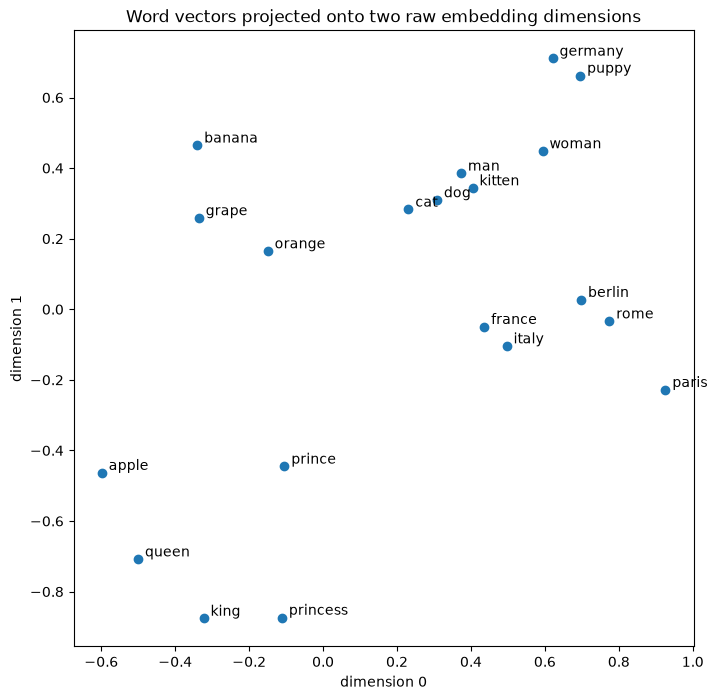

In [14]:
words = [
    "king", "queen", "man", "woman", "prince", "princess",
    "dog", "cat", "puppy", "kitten",
    "france", "paris", "italy", "rome", "germany", "berlin",
    "apple", "banana", "orange", "grape",
]

raw_vectors = np.array([vectors[w] for w in words])

dim1, dim2 = 0, 1
plt.figure(figsize=(8, 8))
plt.scatter(raw_vectors[:, dim1], raw_vectors[:, dim2])
for word, (x, y) in zip(words, raw_vectors[:, [dim1, dim2]]):
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 2))
plt.xlabel(f"dimension {dim1}")
plt.ylabel(f"dimension {dim2}")
plt.title("Word vectors projected onto two raw embedding dimensions")
plt.show()

### 4b. PCA

A better 2D summary: PCA finds the 2 directions (linear combinations of all 100 dimensions)
that capture the most variance across these particular words, then projects onto those.
Related words (royalty, animals, countries/capitals, fruit) should cluster together more
clearly than in the raw-dimension plot above.

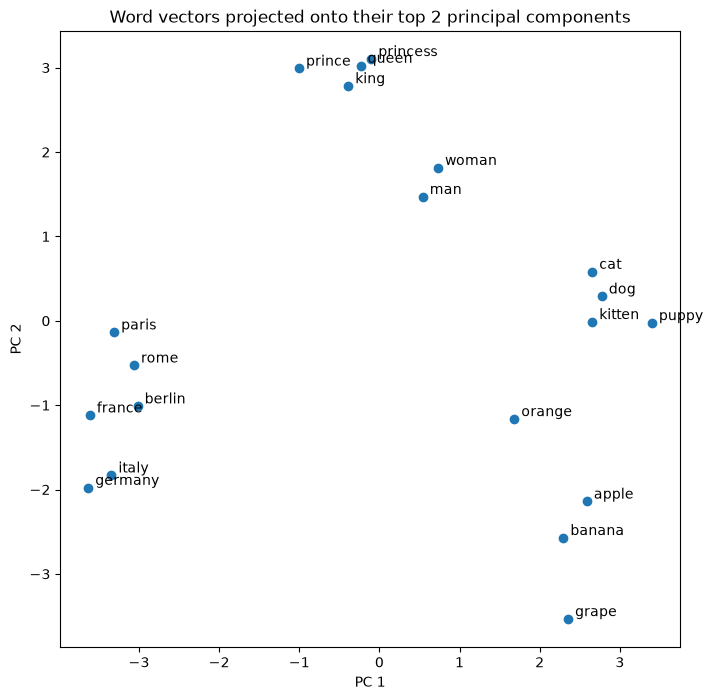

variance explained by these 2 components: 43.3%


In [15]:
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(raw_vectors)

plt.figure(figsize=(8, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
for word, (x, y) in zip(words, vectors_2d):
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 2))
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Word vectors projected onto their top 2 principal components")
plt.show()

print(f"variance explained by these 2 components: {pca.explained_variance_ratio_.sum():.1%}")

## 5. Addition and subtraction

Word embeddings are famous for capturing some analogies as roughly linear relationships:
the vector offset from `man` to `king` is similar to the offset from `woman` to `queen`.
So `king - man + woman` should land close to `queen`.

In [17]:
analogy_vector = vectors["king"] - vectors["man"] + vectors["woman"]

exclude = {"king", "man", "woman"}
similarities = []
for word in vectors.index_to_key[:50_000]:  # limit to the most frequent words, for speed
    if word in exclude:
        continue
    similarities.append((word, cosine_similarity(analogy_vector, vectors[word])))

similarities.sort(key=lambda pair: pair[1], reverse=True)

print("Nearest words to king - man + woman (computed manually):")
for word, score in similarities[:8]:
    print(f"    {word:<15} cosine similarity = {score:.3f}")

Nearest words to king - man + woman (computed manually):
    queen           cosine similarity = 0.783
    monarch         cosine similarity = 0.693
    throne          cosine similarity = 0.683
    daughter        cosine similarity = 0.681
    prince          cosine similarity = 0.671
    princess        cosine similarity = 0.664
    mother          cosine similarity = 0.658
    elizabeth       cosine similarity = 0.656


In [20]:
print("Using gensim's built-in most_similar(positive=[king, woman], negative=[man]):")
for word, score in vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=8):
    print(f"    {word:<15} cosine similarity = {score:.3f}")

Using gensim's built-in most_similar(positive=[king, woman], negative=[man]):
    queen           cosine similarity = 0.770
    monarch         cosine similarity = 0.684
    throne          cosine similarity = 0.676
    daughter        cosine similarity = 0.659
    princess        cosine similarity = 0.652
    prince          cosine similarity = 0.652
    elizabeth       cosine similarity = 0.646
    mother          cosine similarity = 0.631
